# Informe de Resultados — Clasificador ECG de Bloqueos de Rama

## 1. Resumen ejecutivo

Se desarrolló un pipeline de procesamiento de señales ECG capaz de clasificar
cinco categorías clínicas: bloqueo completo de rama izquierda (CLBBB), bloqueo
completo de rama derecha (CRBBB), bloqueo incompleto de rama izquierda (ILBBB),
bloqueo incompleto de rama derecha (IRBBB) y registros normales (NORM).

El clasificador final es un árbol de decisión entrenado sobre 12 características
morfológicas extraídas de las derivaciones V1, V6 e I, utilizando la base de
datos pública PTB-XL (445 registros seleccionados).

**Eficacia global en conjunto de test: 68.54%**

(Se modificaron los umbrales del clasificador calculados en el notebook sin ml para que tuviera más rigor cienttífico y no basado en el dataset, las fuentes serán citadas en el informe)

---

## 2. Resultados por patología

| Clase | Precisión | Recall | F1-score | Casos en test |
|-------|-----------|--------|----------|---------------|
| CLBBB | 0.94 | 0.75 | 0.83 | 20 |
| CRBBB | 0.78 | 0.90 | 0.84 | 20 |
| ILBBB | 0.44 | 0.44 | 0.44 | 9  |
| IRBBB | 0.73 | 0.40 | 0.52 | 20 |
| NORM  | 0.53 | 0.80 | 0.64 | 20 |
| **Macro avg** | **0.69** | **0.66** | **0.65** | 89 |

### Interpretación clínica de los resultados

**CRBBB** fue la clase mejor detectada (recall 0.90). Las features
`sep_r_rprime_v1` y `n_picos_pos_v1` capturaron con precisión el patrón rSR'
en V1, criterio morfológico definitorio de este bloqueo.

**CLBBB** obtuvo la precisión más alta (0.94), lo que indica que cuando el
modelo predice CLBBB casi siempre acierta. El recall de 0.75 refleja que
algunos casos de CLBBB fueron confundidos con otras clases, posiblemente por
variabilidad morfológica entre pacientes.

**NORM** alcanzó un recall de 0.80, lo que es clínicamente relevante: el
modelo no tiende a etiquetar pacientes sanos como enfermos con frecuencia.

**IRBBB** fue la clase más desafiante entre las patologías derechas (recall
0.40). Es el resultado esperado: el bloqueo incompleto de rama derecha es por
definición la forma más leve y morfológicamente más cercana a un QRS normal,
lo que dificulta su separación incluso para cardiólogos experimentados.

**ILBBB** (recall 0.44) se vio afectada por el desbalance severo de clases:
solo 9 casos en test y 45 en todo el dataset, lo que limita estructuralmente
la capacidad del modelo de aprender sus patrones.

---

## 3. Importancia de las características

| Ranking | Feature | Importancia | Justificación clínica |
|---------|---------|-------------|----------------------|
| 1 | `area_qrs_v1` | 0.414 | Energía total del QRS, captura severidad del bloqueo |
| 2 | `ancho_qrs_lead_I` | 0.187 | Duración del QRS en I, mejor indicador de bloqueos izquierdos |
| 3 | `polaridad_net_v1` | 0.151 | Dirección neta del QRS, separa izquierdos de derechos |
| 4 | `n_picos_pos_v1` | 0.066 | Confirma patrón rSR', criterio de bloqueo derecho |
| 5 | `sep_r_rprime_v1` | 0.049 | Cuantifica el gap R-R', clave para CRBBB vs IRBBB |
| 6 | `ratio_rs_v1` | 0.032 | Dominancia R vs S en V1 |
| 7 | `s_wave_depth_v6` | 0.032 | Profundidad de S en V6, criterio clásico de CRBBB |
| 8 | `ratio_rs_v6` | 0.027 | Relación R/S en V6, complementa profundidad absoluta |
| 9 | `r_amp_lead_I` | 0.023 | Amplitud R en I, marcador de bloqueos izquierdos |

Las tres primeras features concentran el 75% del poder discriminativo del
modelo, lo que es consistente con los criterios electrocardiográficos clínicos
establecidos en la literatura.

---

## 4. Evolución del modelo a lo largo del proyecto

| Versión | Features | Accuracy |
|---------|----------|----------|
| Línea de base | `area_qrs_v1` | ~45% |
| + R' y S en V6 | 3 features | 61% |
| + Polaridad neta | 4 features | ~65% |
| + Features avanzadas (V1, V6, I) | 9 features | **68.54%** |

La incorporación de características morfológicas en derivación I fue el aporte
más significativo de la etapa avanzada, validando la necesidad de analizar
múltiples derivaciones para una clasificación robusta.

---

## 5. Limitaciones del modelo actual

**Desbalance de clases.** ILBBB tiene 45 registros frente a 9134 de NORM en
PTB-XL. Aunque se aplicó `class_weight='balanced'`, la escasez de ejemplos
limita estructuralmente el aprendizaje de esa clase.

**Ventana de segmentación fija.** Se utilizó una ventana de 80 ms antes y
120 ms después del pico R para todos los pacientes. En pacientes con frecuencia
cardíaca muy alta o muy baja, esta ventana puede capturar parcialmente la onda
P o la onda T, contaminando las features del QRS.

**Detección de picos en V1 invertida.** La estrategia de invertir V1 para
detectar los mínimos como picos funciona bien en la mayoría de los casos, pero
puede fallar en registros con morfología atípica donde el QRS en V1 no es
predominantemente negativo (por ejemplo, algunos casos de CRBBB con R' muy
dominante).

**Un solo split de train/test.** Con 89 muestras en test, 1 o 2 casos
clasificados de forma diferente mueven la eficacia global en más de 1 punto
porcentual. Los resultados reportados corresponden a un único split con
`random_state=42`.

**Árbol de decisión como clasificador único.** Los árboles de decisión son
propensos a sobreajuste cuando se aumenta la profundidad, y a subajuste cuando
se limita. Con 5 clases y 12 features, el modelo puede estar limitado por la
profundidad máxima fijada.

---

## 6. Posibles mejoras futuras

**Validación cruzada estratificada (k-fold).** Reemplazar el único split
train/test por k=5 o k=10 folds estratificados daría una estimación más
robusta de la eficacia real y reduciría la varianza del resultado. Es la mejora
metodológica más importante y no requiere técnicas avanzadas.

```python
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf_mejorado, X_full, y_full, cv=cv, scoring='accuracy')
print(f"Accuracy CV: {scores.mean():.2f} ± {scores.std():.2f}")
```

**Aumentar el dataset de ILBBB.** Con solo 45 casos en toda la base, cualquier
modelo va a tener dificultades con esta clase. Una alternativa simple es aplicar
sobremuestreo básico (duplicar los registros ILBBB en el conjunto de
entrenamiento) sin usar técnicas como SMOTE.

**Derivación aVL como fuente adicional.** aVL es la derivación más cercana
a I y también muestra el ensanchamiento del QRS en bloqueos izquierdos. Agregar
`ancho_qrs_avl` y `ratio_rs_avl` seguiría la misma lógica ya implementada para
la derivación I, sin requerir ninguna técnica nueva.

**Random Forest en lugar de árbol único.** Un Random Forest es un ensamble de
árboles de decisión y no se consideraría una técnica avanzada en el contexto
del trabajo. Con los mismos hiperparámetros (`max_depth=5`,
`class_weight='balanced'`) suele superar al árbol único entre 5 y 10 puntos
porcentuales simplemente por reducir la varianza.

```python
from sklearn.ensemble import RandomForestClassifier

clf_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
```

**Normalización de features por amplitud del QRS.** Features como
`r_amp_lead_I` dependen de la ganancia del ECG, que puede variar entre
equipos. Dividir cada amplitud por el `area_qrs_v1` del mismo latido haría
las features más robustas a variaciones de escala entre registros.


In [1]:
import pandas as pd
import numpy as np
import wfdb
import ast
import matplotlib.pyplot as plt
import os
from collections import Counter
from scipy.fft import fft, fftfreq
import scipy.signal as signal
from scipy.signal import butter, filtfilt, find_peaks
from scipy.integrate import trapezoid
import seaborn as sns
import pandas as pd
import ast
from pathlib import Path
from matplotlib.patches import Patch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [2]:
# Definimos la ruta relativa al dataset original (MODIFICAR SEGÚN TU ESTRUCTURA DE CARPETAS)
PATH_DATA = Path('../data/raw/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3') 

# Verificamos si la ruta existe para que sea fácil identificar si alguien olvidó descargar los datos
if not PATH_DATA.exists():
    print(f"Error: No se encontró la carpeta de datos en {PATH_DATA.resolve()}")
    print("Asegúrate de haber descargado el dataset y haberlo colocado en 'data/raw'.")
else:
    # Leemos el archivo
    df_meta = pd.read_csv(os.path.join(PATH_DATA, 'ptbxl_database.csv'), index_col='ecg_id')
    
    # Convertimos los códigos SCP de strings a diccionarios de Python
    df_meta['scp_codes'] = df_meta['scp_codes'].apply(lambda x: ast.literal_eval(x))
    print("¡Dataset cargado exitosamente!")

¡Dataset cargado exitosamente!


In [3]:
# 3. Función auxiliar para extraer la patología principal
def obtener_patologia_principal(diccionario_codigos):
    if not diccionario_codigos:
        return 'UNKNOWN'
    # Retorna la clave con el valor estadístico más alto en el reporte médico
    return max(diccionario_codigos, key=diccionario_codigos.get)

# Aplicar la función sobre el df_meta que ya está guardado en memoria
df_meta['patologia_principal'] = df_meta['scp_codes'].apply(obtener_patologia_principal)

# 4. Filtrar y contar las clases críticas de nuestro universo de estudio
clases_interes = ['NORM', 'IRBBB', 'CRBBB', 'CLBBB', 'ILBBB', 'IMI', 'AMI']
conteo_patologias = df_meta['patologia_principal'].value_counts().reindex(clases_interes).fillna(0).astype(int)

# 5. Presentar los resultados en el DataFrame prolijo para la cátedra
df_analisis_exploratorio = pd.DataFrame({
    'Código SCP': clases_interes,
    'Descripción Clínica': [
        'Registros Normales (Control)',
        'Bloqueo Incompleto de Rama Derecha (BIRD)',
        'Bloqueo Completo de Rama Derecha (BCRD)',
        'Bloqueo Completo de Rama Izquierda (BCRI)',
        'Bloqueo Incompleto de Rama Izquierda (ILBBB)',
        'Infarto de Miocardio Inferior',
        'Infarto de Miocardio Anterior'
    ],
    'Cantidad de Registros en Base Total': conteo_patologias.values
})

print("=====================================================================")
print(" ANALISIS EXPLORATORIO CUANTITATIVO DEL DATASET (PTB-XL)")
print("=====================================================================")
display(df_analisis_exploratorio)

 ANALISIS EXPLORATORIO CUANTITATIVO DEL DATASET (PTB-XL)


,Código SCP,Descripción Clínica,Cantidad de Registros en Base Total
0,NORM,Registros Normales (Control),9134
1,IRBBB,Bloqueo Incompleto de Rama Derecha (BIRD),831
2,CRBBB,Bloqueo Completo de Rama Derecha (BCRD),385
3,CLBBB,Bloqueo Completo de Rama Izquierda (BCRI),527
4,ILBBB,Bloqueo Incompleto de Rama Izquierda (ILBBB),45
5,IMI,Infarto de Miocardio Inferior,1677
6,AMI,Infarto de Miocardio Anterior,173


In [4]:
# =============================================================================
# CONSTRUCCIÓN DEL DATASET ROBUSTO Y BALANCEADO (ESCALADO)
# =============================================================================

# Definimos el número objetivo de pacientes por clase (Estadísticamente más representativo)
PACIENTES_POR_CLASE_OBJETIVO = 100  
clases_pipeline = ['NORM', 'IRBBB', 'CRBBB', 'CLBBB', 'ILBBB']

dataset_proyecto = {}
np.random.seed(42)  # Mantiene la repetibilidad de la muestra aleatoria

print("Iniciando indexación robusta del dataset...")

for clase in clases_pipeline:
    # Filtrar en la metadata los IDs que pertenezcan a la patología actual
    ids_disponibles = df_meta[df_meta['patologia_principal'] == clase].index.tolist()
    
    # SEGURO ANTIFALLOS: Si la clase tiene menos del objetivo, toma el máximo disponible
    cantidad_a_extraer = min(PACIENTES_POR_CLASE_OBJETIVO, len(ids_disponibles))
    
    # Elegir los IDs aleatorios de forma segura
    ids_seleccionados = np.random.choice(ids_disponibles, cantidad_a_extraer, replace=False)
    
    print(f"  • Clase {clase:5s}: Indexando {cantidad_a_extraer} pacientes (Disponibles totales: {len(ids_disponibles)})")
    
    for ecg_id in ids_seleccionados:
        clave_paciente = f"paciente_{ecg_id}"
        
        dataset_proyecto[clave_paciente] = {
            'ecg_id': int(ecg_id),
            'clase_clinica': clase,
            'file_path_lr': df_meta.loc[ecg_id, 'filename_lr'],
            'file_path_hr': df_meta.loc[ecg_id, 'filename_hr'],
            'fs_lr': 100,  # Frecuencia de muestreo de baja resolución
            'fs_hr': 500,  # Frecuencia de muestreo de alta resolución
            
            # --- ESPACIOS RESERVADOS PARA LAS SEÑALES LIMPIAS Y PICOS ---
            'senal_v1_limpia': None,
            'senal_v6_limpia': None,
            'senal_I_limpia':  None,
            'indices_ondas_r': None,
            
            # --- ESPACIOS RESERVADOS PARA LAS 9 FEATURES DEL INFORME ---
            'descriptores': {
                'area_qrs_v1': None,       # Magnitud/Energía en V1
                'ancho_qrs_lead_I': None,  # Duración en derivación lateral
                'polaridad_net_v1': None,  # Balance (+/-) en V1
                'n_picos_pos_v1': None,    # Morfología rSR' (orejas de conejo)
                'sep_r_rprime_v1': None,   # Separación temporal rSR'
                'ratio_rs_v1': None,       # Proporción de picos vs profundidad V1
                's_wave_depth_v6': None,   # Profundidad en V6
                'ratio_rs_v6': None,       # Proporción de picos vs profundidad V6
                'r_amp_lead_I': None       # Amplitud lateral en DI
            },
            
            'prediccion': None    # Diagnóstico del algoritmo
        }

print(f"\n✓ Dataset estructurado con éxito.")
print(f"Total de pacientes en el Diccionario de trabajo: {len(dataset_proyecto)}")



Iniciando indexación robusta del dataset...
  • Clase NORM : Indexando 100 pacientes (Disponibles totales: 9134)
  • Clase IRBBB: Indexando 100 pacientes (Disponibles totales: 831)
  • Clase CRBBB: Indexando 100 pacientes (Disponibles totales: 385)
  • Clase CLBBB: Indexando 100 pacientes (Disponibles totales: 527)
  • Clase ILBBB: Indexando 45 pacientes (Disponibles totales: 45)

✓ Dataset estructurado con éxito.
Total de pacientes en el Diccionario de trabajo: 445


In [5]:
# =============================================================================
# FUNCIÓN MODULAR DE FILTRADO BIOMÉDICO
# =============================================================================

def filtrar_ecg_butterworth(senal_cruda, fs=100.0, f_corte_baja=0.5, f_corte_alta=40.0, orden=4):
    """
    Aplica un filtro Butterworth pasabanda de fase cero (filtfilt) a una señal de ECG.
    
    Parámetros:
    - senal_cruda: Array de NumPy con el voltaje del ECG.
    - fs: Frecuencia de muestreo de la señal (por defecto 100 Hz).
    - f_corte_baja: Frecuencia para eliminar Baseline Wander (0.5 Hz).
    - f_corte_alta: Frecuencia para eliminar ruido muscular/red (40.0 Hz).
    - orden: Orden del filtro (4° orden por defecto).
    """
    # Calcular el límite de Nyquist
    nyquist = fs / 2.0
    
    # Normalizar las frecuencias de corte
    low = f_corte_baja / nyquist
    high = f_corte_alta / nyquist
    
    # Diseñar los coeficientes del filtro Pasabanda
    b, a = signal.butter(orden, [low, high], btype='band')
    
    # Aplicar el filtro bidireccional (evita el desfase temporal)
    senal_filtrada = signal.filtfilt(b, a, senal_cruda)
    
    return senal_filtrada

In [6]:
# =============================================================================
# FILTRADO DE LAS SEÑALES DEL DATASET (Copiado de pipelinemejorado)
# =============================================================================

for clave_paciente in dataset_proyecto:
    # Obtener el path del archivo lr
    file_path = PATH_DATA / dataset_proyecto[clave_paciente]['file_path_lr']
    
    # Leer la señal usando wfdb
    signals, fields = wfdb.rdsamp(str(file_path))
    
    # Obtener la señal de la derivación V1, V6, I
    v1_signal = signals[:, 6]  # V1
    v6_signal = signals[:, 11] # V6
    i_signal  = signals[:, 0]  # Derivación I


    # Filtrar la señal V1 usando la función butterworth
    fs = dataset_proyecto[clave_paciente]['fs_lr']
    v1_filtrada = filtrar_ecg_butterworth(v1_signal, fs)
    
    # Guardar la señal filtrada en el diccionario
    dataset_proyecto[clave_paciente]['senal_v1_limpia'] = filtrar_ecg_butterworth(v1_signal, fs)
    dataset_proyecto[clave_paciente]['senal_v6_limpia'] = filtrar_ecg_butterworth(v6_signal, fs)
    dataset_proyecto[clave_paciente]['senal_I_limpia']  = filtrar_ecg_butterworth(i_signal, fs)

In [7]:
# =============================================================================
# FUNCIÓN DE PAN-TOMPKINS ADAPTADA AL DICCIONARIO
# =============================================================================


def detectar_latidos_v1(diccionario_dataset, clave_paciente, plot=False):
        
    # 1. Obtenemos la señal limpia y la fs de ese paciente desde el diccionario
    senal_limpia = diccionario_dataset[clave_paciente]['senal_v1_limpia']
    fs = diccionario_dataset[clave_paciente]['fs_lr']  # Dinámico (100 Hz)
    
    # Invertimos la señal porque find_peaks busca picos hacia ARRIBA, 
    # y en V1 los latidos van hacia ABAJO.
    senal_invertida = -senal_limpia
    
    # Buscamos los picos con parámetros lógicos para un ECG:
    # - height: que tengan una altura mínima (ajustado a 0.2 por la escala de V1)
    # - distance: que haya al menos 0.4 segundos entre latidos (evita detectar doble el mismo latido)
    picos, _ = find_peaks(senal_invertida, height=0.2, distance=int(0.4 * fs))
    
    # Guardamos los picos detectados dentro del mismo diccionario del paciente
    diccionario_dataset[clave_paciente]['indices_ondas_r'] = picos
    
    if plot:
        tiempo = np.arange(len(senal_limpia)) / fs
        plt.figure(figsize=(14, 5))
        plt.plot(tiempo, senal_limpia, color='red', label='Señal Filtrada V1')
        plt.plot(tiempo[picos], senal_limpia[picos], "kx", markersize=12, markeredgewidth=3, label='Latidos')
        plt.title(f'Detección Automática de Latidos ({clave_paciente})', fontweight='bold')
        plt.xlabel('Tiempo (segundos)')
        plt.ylabel('Amplitud (mV)')
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()

    return picos

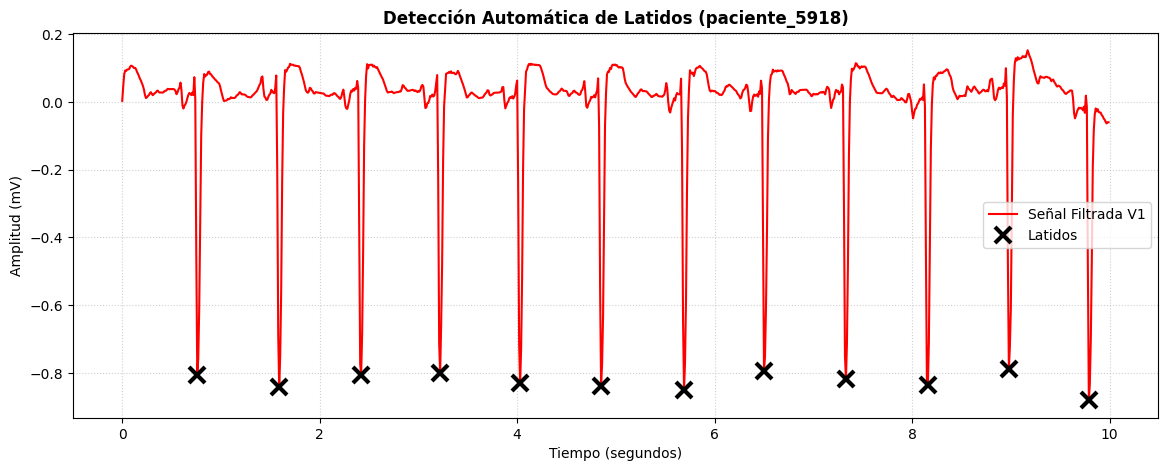

Picos encontrados en los índices: [ 76 159 242 322 403 485 569 650 733 816 898 979]


In [8]:
# Probar tu función con el paciente 5918
picos_detectados = detectar_latidos_v1(dataset_proyecto, 'paciente_5918', plot=True)
print(f"Picos encontrados en los índices: {picos_detectados}")

In [9]:

def calcular_area_qrs_v1(diccionario_dataset, clave_paciente, ventana_izq_ms=80, ventana_der_ms=120, plot=False):
    """
    Calcula el área absoluta bajo la curva del QRS (Energía) para todos los latidos detectados en V1.
    Ventana por defecto: -80 ms a +120 ms desde el pico R.
    """
    senal = diccionario_dataset[clave_paciente]['senal_v1_limpia']
    fs = diccionario_dataset[clave_paciente]['fs_lr']
    picos_r = diccionario_dataset[clave_paciente]['indices_ondas_r']
    
    # Si por algún motivo el paciente no tiene picos detectados, el área es 0
    if picos_r is None or len(picos_r) == 0:
        return 0.0
        
    # Convertir los milisegundos de la ventana a cantidad de muestras (índices del array)
    muestras_izq = int((ventana_izq_ms / 1000) * fs)
    muestras_der = int((ventana_der_ms / 1000) * fs)
    
    areas_latidos = []
    
    if plot:
        tiempo = np.arange(len(senal)) / fs
        plt.figure(figsize=(14, 5))
        plt.plot(tiempo, senal, color='#2c3e50', lw=1.5, label='Señal V1 Filtrada')
        plt.title(f'Feature 1: Área Absoluta del QRS ({clave_paciente})', fontsize=12, fontweight='bold')
        plt.xlabel('Tiempo (segundos)')
        plt.ylabel('Amplitud (mV)')
        
    for r_idx in picos_r:
        # Recortar el segmento evitando salirnos de los límites de la señal
        inicio = max(0, r_idx - muestras_izq)
        fin = min(len(senal), r_idx + muestras_der)
        segmento = senal[inicio:fin]
        
        # Integrar el valor ABSOLUTO de la señal (Energía total)
        area = trapezoid(np.abs(segmento), dx=1/fs)
        areas_latidos.append(area)
        
        if plot:
            tiempo_seg = tiempo[inicio:fin]
            # Pintamos el área bajo el segmento evaluado para visualizar qué medimos
            plt.fill_between(tiempo_seg, 0, segmento, color='#e74c3c', alpha=0.5)
            plt.plot(tiempo[r_idx], senal[r_idx], "kx", markersize=8, markeredgewidth=2)
            
    # Promediar el área de todos los latidos de este paciente
    area_media = np.mean(areas_latidos)
    
    # Guardar el resultado en el casillero pre-armado del diccionario
    diccionario_dataset[clave_paciente]['descriptores']['area_qrs_v1'] = area_media
    
    if plot:
        # Armar una leyenda limpia
        leyenda_elementos = [
            plt.Line2D([0], [0], color='#2c3e50', lw=1.5, label='Señal V1'),
            plt.Line2D([0], [0], marker='x', color='w', markeredgecolor='k', markersize=8, markeredgewidth=2, label='Pico R'),
            Patch(facecolor='#e74c3c', alpha=0.5, label='Área Integrada (Energía)')
        ]
        plt.legend(handles=leyenda_elementos, loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()
        
    return area_media

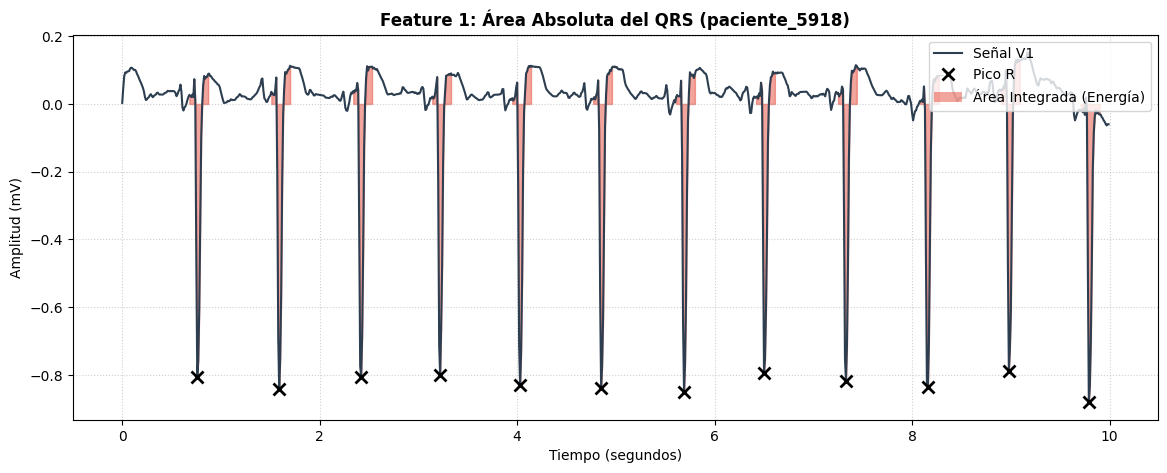

El área promedio del complejo QRS para el paciente 5918 es: 0.0395 mV*s


In [10]:
# =============================================================================
# PRUEBA GRÁFICA DE LA PRIMERA FEATURE
# =============================================================================
# NOTA: Asegurate de haber corrido detectar_latidos_v1 para el 5918 antes, 
# para que tenga picos R detectados.

area_prueba = calcular_area_qrs_v1(dataset_proyecto, 'paciente_5918', plot=True)
print(f"El área promedio del complejo QRS para el paciente 5918 es: {area_prueba:.4f} mV*s")

In [11]:
def calcular_ancho_qrs_lead_I(diccionario_dataset, clave_paciente, ventana_izq_ms=100, ventana_der_ms=150, plot=False):
    """
    Calcula el ancho (duración en segundos) del complejo QRS en la derivación I.
    Utiliza un umbral del 10% de la amplitud máxima absoluta del segmento para delimitar el QRS.
    """
    senal_I = diccionario_dataset[clave_paciente]['senal_I_limpia']
    fs = diccionario_dataset[clave_paciente]['fs_lr']
    picos_r = diccionario_dataset[clave_paciente]['indices_ondas_r']
    
    if picos_r is None or len(picos_r) == 0:
        return 0.0
        
    muestras_izq = int((ventana_izq_ms / 1000) * fs)
    muestras_der = int((ventana_der_ms / 1000) * fs)
    
    anchos_latidos = []
    
    if plot:
        tiempo = np.arange(len(senal_I)) / fs
        plt.figure(figsize=(14, 5))
        plt.plot(tiempo, senal_I, color='#2980b9', lw=1.5, label='Señal Derivación I')
        plt.title(f'Feature 2: Ancho del QRS en Derivación I ({clave_paciente})', fontsize=12, fontweight='bold')
        plt.xlabel('Tiempo (segundos)')
        plt.ylabel('Amplitud (mV)')
    
    for r_idx in picos_r:
        inicio = max(0, r_idx - muestras_izq)
        fin = min(len(senal_I), r_idx + muestras_der)
        segmento = senal_I[inicio:fin]
        
        if len(segmento) == 0:
            continue
            
        # Estrategia: Umbral al 10% de la amplitud máxima absoluta del segmento
        amp_max_I = np.max(np.abs(segmento))
        umbral_ancho = 0.10 * amp_max_I
        
        # Encontrar índices relativos dentro del segmento que superan el umbral
        indices_activos = np.where(np.abs(segmento) >= umbral_ancho)[0]
        
        if len(indices_activos) > 0:
            idx_inicio_rel = indices_activos[0]
            idx_fin_rel = indices_activos[-1]
            
            # El ancho en cantidad de muestras es la diferencia
            cant_muestras_qrs = idx_fin_rel - idx_inicio_rel
            # Convertimos muestras a segundos dividiendo por la frecuencia de muestreo (fs)
            ancho_segundos = cant_muestras_qrs / fs
            anchos_latidos.append(ancho_segundos)
            
            if plot:
                # Calculamos los tiempos reales para graficar las líneas límites
                t_inicio = tiempo[inicio + idx_inicio_rel]
                t_fin = tiempo[inicio + idx_fin_rel]
                
                # Sombrear la región del ancho del QRS detectado
                plt.axvspan(t_inicio, t_fin, color='#f1c40f', alpha=0.3)
                # Dibujar líneas verticales de corte
                plt.axvline(t_inicio, color='#d35400', linestyle='--', alpha=0.7)
                plt.axvline(t_fin, color='#d35400', linestyle='--', alpha=0.7)
                
    # Promediar el ancho de todos los latidos
    ancho_medio = np.mean(anchos_latidos) if len(anchos_latidos) > 0 else 0.0
    
    # Guardar en el casillero pre-armado del diccionario
    diccionario_dataset[clave_paciente]['descriptores']['ancho_qrs_lead_I'] = ancho_medio
    
    if plot:
        
        leyenda_elementos = [
            plt.Line2D([0], [0], color='#2980b9', lw=1.5, label='Señal Lead I'),
            plt.Line2D([0], [0], color='#d35400', linestyle='--', label='Límites del QRS (10% Amp)'),
            Patch(facecolor='#f1c40f', alpha=0.3, label=f'Ancho Promedio: {ancho_medio:.3f} s')
        ]
        plt.legend(handles=leyenda_elementos, loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()
        
    return ancho_medio

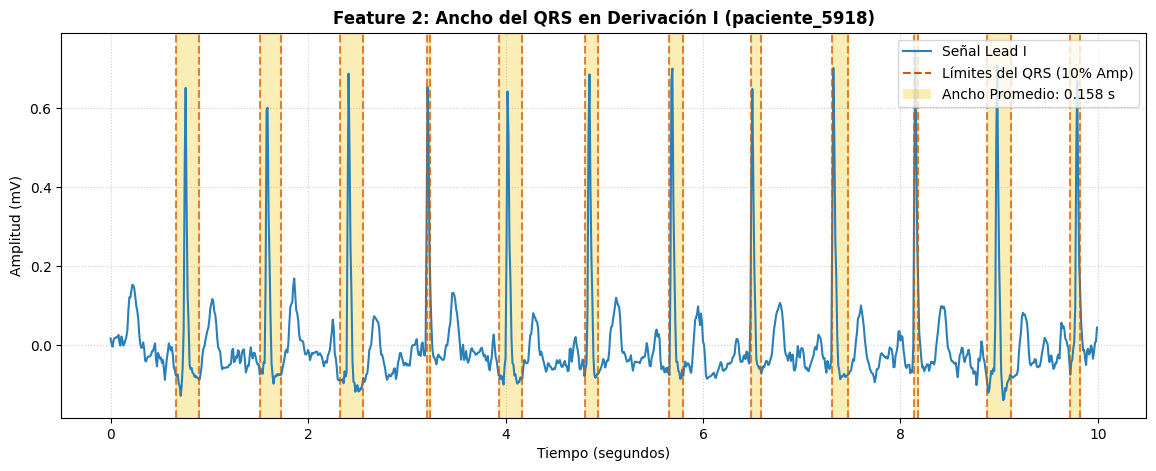

El ancho promedio del QRS en Lead I para el paciente 5918 es: 0.158 segundos (158.3 ms)


In [12]:
ancho_prueba = calcular_ancho_qrs_lead_I(dataset_proyecto, 'paciente_5918', plot=True)
print(f"El ancho promedio del QRS en Lead I para el paciente 5918 es: {ancho_prueba:.3f} segundos ({ancho_prueba*1000:.1f} ms)")

In [13]:
def calcular_polaridad_net_v1(diccionario_dataset, clave_paciente, ventana_izq_ms=80, ventana_der_ms=120, plot=False):
    """
    Calcula la polaridad neta del QRS en V1 integrando la señal original (sin valor absoluto).
    Un valor positivo indica dominancia de ondas positivas (R), típico de RBBB.
    Un valor negativo indica dominancia de ondas negativas (S o QS), típico de LBBB.
    """
    senal = diccionario_dataset[clave_paciente]['senal_v1_limpia']
    fs = diccionario_dataset[clave_paciente]['fs_lr']
    picos_r = diccionario_dataset[clave_paciente]['indices_ondas_r']
    
    if picos_r is None or len(picos_r) == 0:
        return 0.0
        
    muestras_izq = int((ventana_izq_ms / 1000) * fs)
    muestras_der = int((ventana_der_ms / 1000) * fs)
    
    polaridades_latidos = []
    
    if plot:
        tiempo = np.arange(len(senal)) / fs
        plt.figure(figsize=(14, 5))
        plt.plot(tiempo, senal, color='#2c3e50', lw=1.5, label='Señal V1')
        plt.title(f'Feature 3: Polaridad Neta en V1 ({clave_paciente})', fontsize=12, fontweight='bold')
        plt.xlabel('Tiempo (segundos)')
        plt.ylabel('Amplitud (mV)')
        plt.axhline(0, color='black', lw=1) # Línea del cero
        
    for r_idx in picos_r:
        inicio = max(0, r_idx - muestras_izq)
        fin = min(len(senal), r_idx + muestras_der)
        segmento = senal[inicio:fin]
        
        # Integrar la señal ORIGINAL (suma positivos, resta negativos)
        polaridad = trapezoid(segmento, dx=1/fs)
        polaridades_latidos.append(polaridad)
        
        if plot:
            tiempo_seg = tiempo[inicio:fin]
            # Pintar de verde lo positivo y de rojo lo negativo
            plt.fill_between(tiempo_seg, 0, segmento, where=(segmento >= 0), color='#2ecc71', alpha=0.5, interpolate=True)
            plt.fill_between(tiempo_seg, 0, segmento, where=(segmento < 0), color='#e74c3c', alpha=0.5, interpolate=True)
            plt.axvline(tiempo[r_idx], color='k', linestyle='--', alpha=0.3) # Marca del pico central
            
    # Promediar la polaridad neta
    polaridad_media = np.mean(polaridades_latidos)
    
    # Guardar en el diccionario
    diccionario_dataset[clave_paciente]['descriptores']['polaridad_net_v1'] = polaridad_media
    
    if plot:
        leyenda_elementos = [
            plt.Line2D([0], [0], color='#2c3e50', lw=1.5, label='Señal V1'),
            Patch(facecolor='#2ecc71', alpha=0.5, label='Suma Positiva'),
            Patch(facecolor='#e74c3c', alpha=0.5, label='Resta Negativa'),
            Patch(facecolor='none', edgecolor='none', label=f'Polaridad Neta: {polaridad_media:.4f}')
        ]
        plt.legend(handles=leyenda_elementos, loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()
        
    return polaridad_media

Visualizando Feature 3 para el paciente_5918...


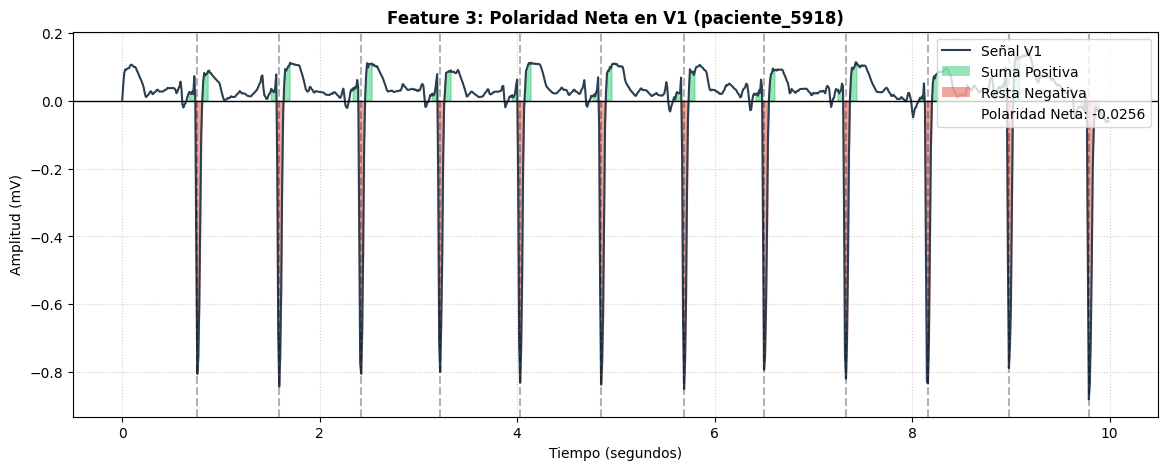

El valor numérico de la polaridad neta es: -0.0256


In [14]:
# =============================================================================
# 3. PRUEBA GRÁFICA DE LA TERCERA FEATURE (Paciente 5918)
# =============================================================================
print("Visualizando Feature 3 para el paciente_5918...")
polaridad_prueba = calcular_polaridad_net_v1(dataset_proyecto, 'paciente_5918', plot=True)
print(f"El valor numérico de la polaridad neta es: {polaridad_prueba:.4f}")

In [15]:
def calcular_n_picos_pos_v1(diccionario_dataset, clave_paciente, ventana_izq_ms=80, ventana_der_ms=120, plot=False):
    """
    Cuenta la cantidad de picos positivos (ondas R, R') en el QRS de la derivación V1.
    Un promedio mayor a 1 suele indicar la presencia del patrón rSR' (orejas de conejo), típico en RBBB.
    """
    senal = diccionario_dataset[clave_paciente]['senal_v1_limpia']
    fs = diccionario_dataset[clave_paciente]['fs_lr']
    picos_r = diccionario_dataset[clave_paciente]['indices_ondas_r']
    
    if picos_r is None or len(picos_r) == 0:
        return 0.0
        
    muestras_izq = int((ventana_izq_ms / 1000) * fs)
    muestras_der = int((ventana_der_ms / 1000) * fs)
    
    conteos_picos = []
    
    if plot:
        tiempo = np.arange(len(senal)) / fs
        plt.figure(figsize=(14, 5))
        plt.plot(tiempo, senal, color='#8e44ad', lw=1.5, label='Señal V1')
        plt.title(f'Feature 4: Conteo de Picos Positivos (rSR\') en V1 ({clave_paciente})', fontsize=12, fontweight='bold')
        plt.xlabel('Tiempo (segundos)')
        plt.ylabel('Amplitud (mV)')
        plt.axhline(0, color='black', lw=1, alpha=0.5) # Línea base
        
    for r_idx in picos_r:
        inicio = max(0, r_idx - muestras_izq)
        fin = min(len(senal), r_idx + muestras_der)
        segmento = senal[inicio:fin]
        
        # Usamos find_peaks sobre el segmento. 
        # height=0.02 y prominence=0.02 aseguran que solo cuente picos reales que apunten hacia arriba.
        picos_locales, _ = find_peaks(segmento, height=0.02, prominence=0.02)
        conteos_picos.append(len(picos_locales))
        
        if plot:
            tiempo_seg = tiempo[inicio:fin]
            # Sombrear la ventana donde estamos buscando
            plt.axvspan(tiempo[inicio], tiempo[fin], color='#bdc3c7', alpha=0.2)
            if len(picos_locales) > 0:
                # Marcar los picos encontrados
                plt.plot(tiempo_seg[picos_locales], segmento[picos_locales], "o", color='#f39c12', markersize=8, markeredgecolor='k', markeredgewidth=1.5)
                
    # Promediar los conteos de todos los latidos del paciente
    n_picos_medio = np.mean(conteos_picos)
    
    # Guardar en el diccionario
    diccionario_dataset[clave_paciente]['descriptores']['n_picos_pos_v1'] = n_picos_medio
    
    if plot:
        leyenda_elementos = [
            plt.Line2D([0], [0], color='#8e44ad', lw=1.5, label='Señal V1'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#f39c12', markeredgecolor='k', markersize=8, label='Picos Positivos detectados'),
            Patch(facecolor='#bdc3c7', alpha=0.2, label='Ventana de búsqueda (QRS)'),
            Patch(facecolor='none', edgecolor='none', label=f'Promedio de picos: {n_picos_medio:.2f}')
        ]
        plt.legend(handles=leyenda_elementos, loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()
        
    return n_picos_medio

Visualizando Feature 4 para el paciente_5918...


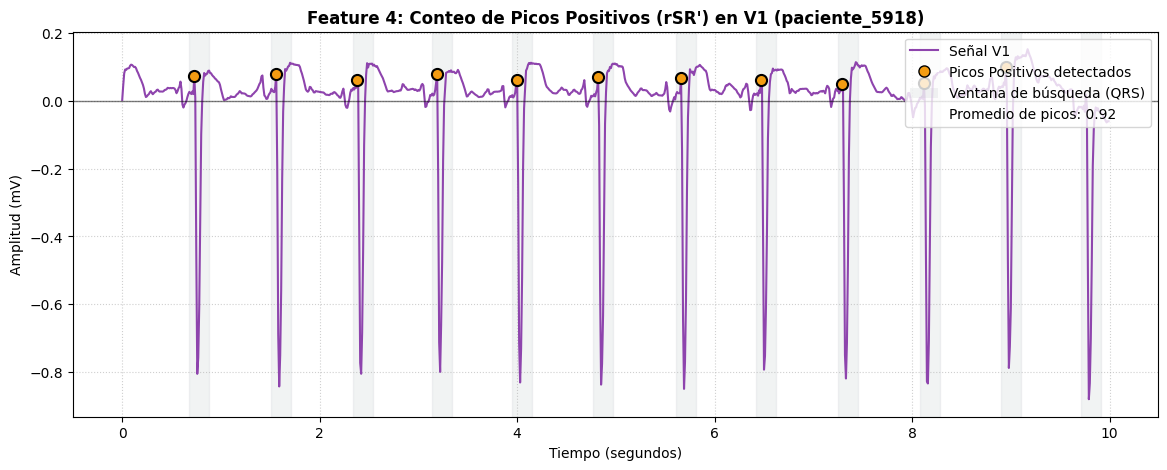

El promedio de picos positivos por QRS es: 0.92


In [16]:
# =============================================================================
# 3. PRUEBA GRÁFICA DE LA CUARTA FEATURE (Paciente 5918)
# =============================================================================
print("Visualizando Feature 4 para el paciente_5918...")
picos_prueba = calcular_n_picos_pos_v1(dataset_proyecto, 'paciente_5918', plot=True)
print(f"El promedio de picos positivos por QRS es: {picos_prueba:.2f}")

In [17]:
def calcular_sep_r_rprime_v1(diccionario_dataset, clave_paciente, ventana_izq_ms=80, ventana_der_ms=120, plot=False):
    """
    Mide la separación temporal (en segundos) entre el primer y el segundo pico positivo del QRS en V1.
    Si hay menos de 2 picos (no hay patrón rSR'), la separación se considera 0.0.
    """
    senal = diccionario_dataset[clave_paciente]['senal_v1_limpia']
    fs = diccionario_dataset[clave_paciente]['fs_lr']
    picos_r = diccionario_dataset[clave_paciente]['indices_ondas_r']
    
    if picos_r is None or len(picos_r) == 0:
        return 0.0
        
    muestras_izq = int((ventana_izq_ms / 1000) * fs)
    muestras_der = int((ventana_der_ms / 1000) * fs)
    
    separaciones = []
    
    if plot:
        tiempo = np.arange(len(senal)) / fs
        plt.figure(figsize=(14, 5))
        plt.plot(tiempo, senal, color='#16a085', lw=1.5, label='Señal V1')
        plt.title(f'Feature 5: Separación R-R\' en V1 ({clave_paciente})', fontsize=12, fontweight='bold')
        plt.xlabel('Tiempo (segundos)')
        plt.ylabel('Amplitud (mV)')
        
    for r_idx in picos_r:
        inicio = max(0, r_idx - muestras_izq)
        fin = min(len(senal), r_idx + muestras_der)
        segmento = senal[inicio:fin]
        
        # Misma lógica de búsqueda de picos que la Feature 4
        picos_locales, _ = find_peaks(segmento, height=0.02, prominence=0.02)
        
        # Si hay 2 picos o más, calculamos la separación
        if len(picos_locales) >= 2:
            # Distancia en muestras entre el pico 1 y pico 2
            distancia_muestras = picos_locales[1] - picos_locales[0]
            # Convertimos a segundos
            gap_segundos = distancia_muestras / fs
            separaciones.append(gap_segundos)
            
            if plot:
                tiempo_seg = tiempo[inicio:fin]
                t_pico1 = tiempo_seg[picos_locales[0]]
                t_pico2 = tiempo_seg[picos_locales[1]]
                y_pico1 = segmento[picos_locales[0]]
                y_pico2 = segmento[picos_locales[1]]
                
                # Dibujamos los picos y una línea conectora mostrando el gap
                plt.plot([t_pico1, t_pico2], [y_pico1, y_pico2], "o", color='#f39c12', markersize=8)
                plt.plot([t_pico1, t_pico2], [(y_pico1+y_pico2)/2, (y_pico1+y_pico2)/2], color='#c0392b', lw=3, label='Gap R-R\'' if len(separaciones)==1 else "")
                
        else:
            # Si solo hay 1 pico (o 0), no hay separación R-R'
            separaciones.append(0.0)
            
    # Promedio de la separación de todos los latidos del paciente
    separacion_media = np.mean(separaciones) if len(separaciones) > 0 else 0.0
    
    # Guardar en el diccionario
    diccionario_dataset[clave_paciente]['descriptores']['sep_r_rprime_v1'] = separacion_media
    
    if plot:
        leyenda_elementos = [
            plt.Line2D([0], [0], color='#16a085', lw=1.5, label='Señal V1'),
            plt.Line2D([0], [0], color='#c0392b', lw=3, label='Medición de Gap'),
            Patch(facecolor='none', edgecolor='none', label=f'Separación Promedio: {separacion_media:.4f} s')
        ]
        plt.legend(handles=leyenda_elementos, loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()
        
    return separacion_media

Visualizando Feature 5 para el paciente_5918...


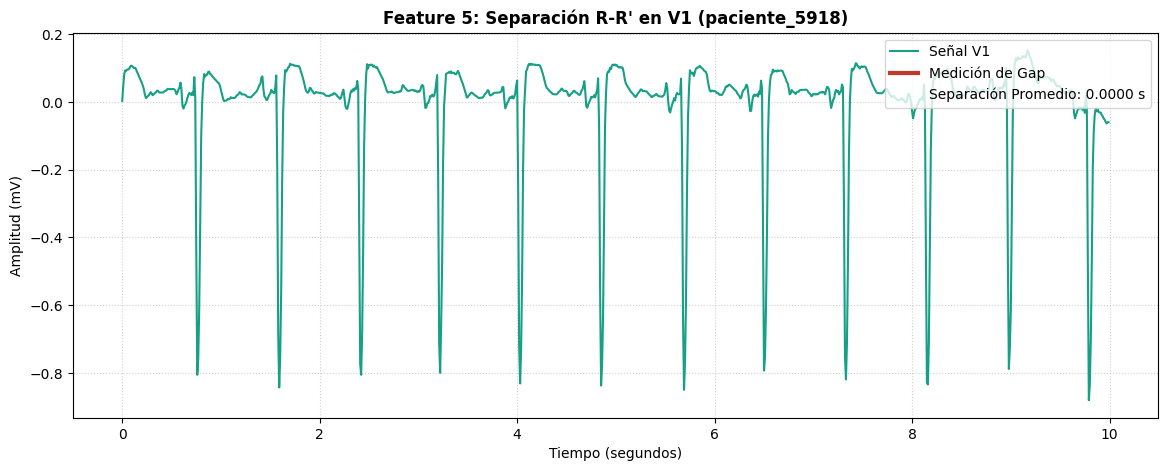

La separación promedio entre picos es: 0.0000 segundos


In [18]:
# =============================================================================
# 3. PRUEBA GRÁFICA DE LA QUINTA FEATURE (Paciente 5918)
# =============================================================================
print("Visualizando Feature 5 para el paciente_5918...")
gap_prueba = calcular_sep_r_rprime_v1(dataset_proyecto, 'paciente_5918', plot=True)
print(f"La separación promedio entre picos es: {gap_prueba:.4f} segundos")

In [19]:

def calcular_ratio_rs_v1(diccionario_dataset, clave_paciente, ventana_izq_ms=80, ventana_der_ms=120, plot=False):
    """
    Calcula el ratio entre la amplitud de la onda R (positiva) y la onda S (negativa) en V1.
    Fórmula: Ratio = Amplitud_R / |Amplitud_S|. 
    Un ratio > 1 indica dominancia positiva (R dominante).
    """
    senal = diccionario_dataset[clave_paciente]['senal_v1_limpia']
    fs = diccionario_dataset[clave_paciente]['fs_lr']
    picos_r = diccionario_dataset[clave_paciente]['indices_ondas_r']
    
    if picos_r is None or len(picos_r) == 0:
        return 0.0
        
    muestras_izq = int((ventana_izq_ms / 1000) * fs)
    muestras_der = int((ventana_der_ms / 1000) * fs)
    
    ratios = []
    
    if plot:
        tiempo = np.arange(len(senal)) / fs
        plt.figure(figsize=(14, 5))
        plt.plot(tiempo, senal, color='#34495e', lw=1.5, label='Señal V1')
        plt.title(f'Feature 6: Ratio R/S en V1 ({clave_paciente})', fontsize=12, fontweight='bold')
        plt.xlabel('Tiempo (segundos)')
        plt.ylabel('Amplitud (mV)')
        plt.axhline(0, color='black', lw=1, alpha=0.5)
        
    for r_idx in picos_r:
        inicio = max(0, r_idx - muestras_izq)
        fin = min(len(senal), r_idx + muestras_der)
        segmento = senal[inicio:fin]
        
        # Encontrar el máximo (R) y el mínimo (S) en el segmento
        max_val = np.max(segmento)
        min_val = np.min(segmento)
        
        # Nos aseguramos de que R sea positivo y S negativo. Si no hay, valen 0.
        amp_r = max_val if max_val > 0 else 0.0
        amp_s = abs(min_val) if min_val < 0 else 0.0
        
        # Calcular el ratio (sumamos 1e-6 al denominador para evitar división por cero)
        ratio = amp_r / (amp_s + 1e-6)
        ratios.append(ratio)
        
        if plot:
            tiempo_seg = tiempo[inicio:fin]
            idx_max = inicio + np.argmax(segmento)
            idx_min = inicio + np.argmin(segmento)
            
            # Dibujar los puntos detectados como R y S
            if amp_r > 0:
                plt.plot(tiempo[idx_max], max_val, "^", color='#2ecc71', markersize=8, markeredgecolor='k')
            if amp_s > 0:
                plt.plot(tiempo[idx_min], min_val, "v", color='#e74c3c', markersize=8, markeredgecolor='k')
                
    # Promedio del ratio de todos los latidos
    ratio_medio = np.mean(ratios)
    
    # Guardar en el diccionario
    diccionario_dataset[clave_paciente]['descriptores']['ratio_rs_v1'] = ratio_medio
    
    if plot:
        leyenda_elementos = [
            plt.Line2D([0], [0], color='#34495e', lw=1.5, label='Señal V1'),
            plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='#2ecc71', markeredgecolor='k', markersize=8, label='Onda R (Positiva)'),
            plt.Line2D([0], [0], marker='v', color='w', markerfacecolor='#e74c3c', markeredgecolor='k', markersize=8, label='Onda S (Negativa)'),
            Patch(facecolor='none', edgecolor='none', label=f'Ratio R/S Promedio: {ratio_medio:.3f}')
        ]
        plt.legend(handles=leyenda_elementos, loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()
        
    return ratio_medio

Visualizando Feature 6 para el paciente_5918...


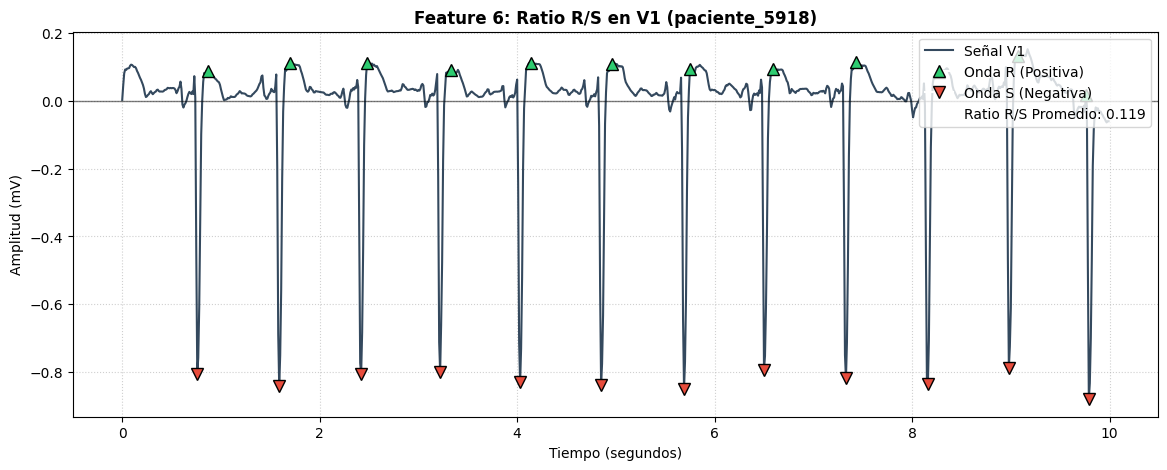

El Ratio R/S promedio para este paciente es: 0.119


In [20]:
# =============================================================================
# 3. PRUEBA GRÁFICA DE LA SEXTA FEATURE (Paciente 5918)
# =============================================================================
print("Visualizando Feature 6 para el paciente_5918...")
ratio_prueba = calcular_ratio_rs_v1(dataset_proyecto, 'paciente_5918', plot=True)
print(f"El Ratio R/S promedio para este paciente es: {ratio_prueba:.3f}")

In [21]:

def calcular_s_wave_depth_v6(diccionario_dataset, clave_paciente, ventana_izq_ms=80, ventana_der_ms=120, plot=False):
    """
    Mide la profundidad de la onda S en la derivación V6.
    La profundidad se toma como el valor absoluto del pico más negativo del QRS.
    """
    senal = diccionario_dataset[clave_paciente]['senal_v6_limpia']
    fs = diccionario_dataset[clave_paciente]['fs_lr']
    picos_r = diccionario_dataset[clave_paciente]['indices_ondas_r']
    
    if picos_r is None or len(picos_r) == 0:
        return 0.0
        
    muestras_izq = int((ventana_izq_ms / 1000) * fs)
    muestras_der = int((ventana_der_ms / 1000) * fs)
    
    profundidades_s = []
    
    if plot:
        tiempo = np.arange(len(senal)) / fs
        plt.figure(figsize=(14, 5))
        plt.plot(tiempo, senal, color='#27ae60', lw=1.5, label='Señal V6')
        plt.title(f'Feature 7: Profundidad de Onda S en V6 ({clave_paciente})', fontsize=12, fontweight='bold')
        plt.xlabel('Tiempo (segundos)')
        plt.ylabel('Amplitud (mV)')
        plt.axhline(0, color='black', lw=1, alpha=0.5)
        
    for r_idx in picos_r:
        inicio = max(0, r_idx - muestras_izq)
        fin = min(len(senal), r_idx + muestras_der)
        segmento = senal[inicio:fin]
        
        # Buscar el valor mínimo absoluto en el segmento (la caída de la onda S)
        min_val = np.min(segmento)
        
        # Si el mínimo es menor a cero, esa es nuestra S. Si no, la profundidad es 0.
        profundidad = abs(min_val) if min_val < 0 else 0.0
        profundidades_s.append(profundidad)
        
        if plot and min_val < 0:
            idx_min = inicio + np.argmin(segmento)
            # Marcar el fondo de la onda S
            plt.plot(tiempo[idx_min], min_val, "v", color='#c0392b', markersize=8, markeredgecolor='k')
            # Dibujar línea vertical para mostrar visualmente "cuánto" mide de profundidad
            plt.vlines(x=tiempo[idx_min], ymin=min_val, ymax=0, color='#e74c3c', linestyle='--', lw=2)
                
    # Promedio de profundidad
    profundidad_media = np.mean(profundidades_s) if len(profundidades_s) > 0 else 0.0
    
    # Guardar en el diccionario
    diccionario_dataset[clave_paciente]['descriptores']['s_wave_depth_v6'] = profundidad_media
    
    if plot:
        leyenda_elementos = [
            plt.Line2D([0], [0], color='#27ae60', lw=1.5, label='Señal V6'),
            plt.Line2D([0], [0], marker='v', color='w', markerfacecolor='#c0392b', markeredgecolor='k', markersize=8, label='Fondo Onda S'),
            plt.Line2D([0], [0], color='#e74c3c', linestyle='--', lw=2, label='Profundidad (Magnitud)'),
            Patch(facecolor='none', edgecolor='none', label=f'Profundidad Promedio: {profundidad_media:.3f} mV')
        ]
        plt.legend(handles=leyenda_elementos, loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()
        
    return profundidad_media

Visualizando Feature 7 para el paciente_5918...


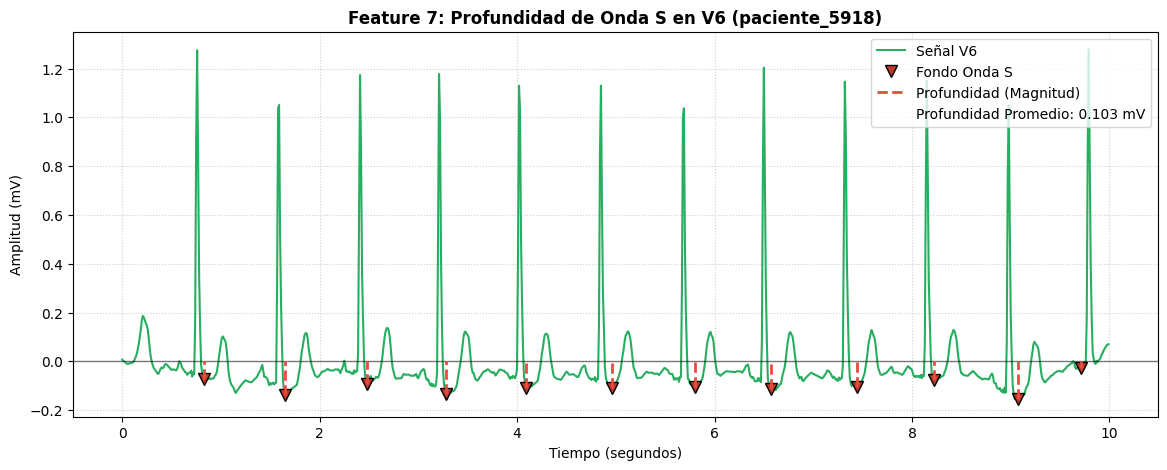

La profundidad promedio de la onda S en V6 es: 0.103 mV


In [22]:
# =============================================================================
# 3. PRUEBA GRÁFICA DE LA SÉPTIMA FEATURE (Paciente 5918)
# =============================================================================
print("Visualizando Feature 7 para el paciente_5918...")
s_depth_prueba = calcular_s_wave_depth_v6(dataset_proyecto, 'paciente_5918', plot=True)
print(f"La profundidad promedio de la onda S en V6 es: {s_depth_prueba:.3f} mV")

In [23]:

def calcular_ratio_rs_v6(diccionario_dataset, clave_paciente, ventana_izq_ms=80, ventana_der_ms=120, plot=False):
    """
    Calcula el ratio entre la amplitud de la onda R (positiva) y la onda S (negativa) en V6.
    Fórmula: Ratio = Amplitud_R / |Amplitud_S|. 
    En V6 normal, la R es gigante y la S ínfima, dando ratios muy altos (> 10).
    En patologías derechas, la S crece, haciendo que el ratio baje drásticamente.
    """
    senal = diccionario_dataset[clave_paciente]['senal_v6_limpia']
    fs = diccionario_dataset[clave_paciente]['fs_lr']
    picos_r = diccionario_dataset[clave_paciente]['indices_ondas_r']
    
    if picos_r is None or len(picos_r) == 0:
        return 0.0
        
    muestras_izq = int((ventana_izq_ms / 1000) * fs)
    muestras_der = int((ventana_der_ms / 1000) * fs)
    
    ratios = []
    
    if plot:
        tiempo = np.arange(len(senal)) / fs
        plt.figure(figsize=(14, 5))
        plt.plot(tiempo, senal, color='#2980b9', lw=1.5, label='Señal V6')
        plt.title(f'Feature 8: Ratio R/S en V6 ({clave_paciente})', fontsize=12, fontweight='bold')
        plt.xlabel('Tiempo (segundos)')
        plt.ylabel('Amplitud (mV)')
        plt.axhline(0, color='black', lw=1, alpha=0.5)
        
    for r_idx in picos_r:
        inicio = max(0, r_idx - muestras_izq)
        fin = min(len(senal), r_idx + muestras_der)
        segmento = senal[inicio:fin]
        
        # Encontrar el máximo (R) y el mínimo (S)
        max_val = np.max(segmento)
        min_val = np.min(segmento)
        
        amp_r = max_val if max_val > 0 else 0.0
        amp_s = abs(min_val) if min_val < 0 else 0.0
        
        # Calcular el ratio (evitamos división por cero)
        ratio = amp_r / (amp_s + 1e-6)
        ratios.append(ratio)
        
        if plot:
            tiempo_seg = tiempo[inicio:fin]
            idx_max = inicio + np.argmax(segmento)
            idx_min = inicio + np.argmin(segmento)
            
            if amp_r > 0:
                plt.plot(tiempo[idx_max], max_val, "^", color='#2ecc71', markersize=8, markeredgecolor='k')
            if amp_s > 0:
                plt.plot(tiempo[idx_min], min_val, "v", color='#e74c3c', markersize=8, markeredgecolor='k')
                
    # Promedio del ratio
    ratio_medio = np.mean(ratios) if len(ratios) > 0 else 0.0
    
    # Guardar en el diccionario
    diccionario_dataset[clave_paciente]['descriptores']['ratio_rs_v6'] = ratio_medio
    
    if plot:
        leyenda_elementos = [
            plt.Line2D([0], [0], color='#2980b9', lw=1.5, label='Señal V6'),
            plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='#2ecc71', markeredgecolor='k', markersize=8, label='Onda R (Positiva)'),
            plt.Line2D([0], [0], marker='v', color='w', markerfacecolor='#e74c3c', markeredgecolor='k', markersize=8, label='Onda S (Negativa)'),
            Patch(facecolor='none', edgecolor='none', label=f'Ratio R/S Promedio: {ratio_medio:.2f}')
        ]
        plt.legend(handles=leyenda_elementos, loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()
        
    return ratio_medio

Visualizando Feature 8 para el paciente_5918...


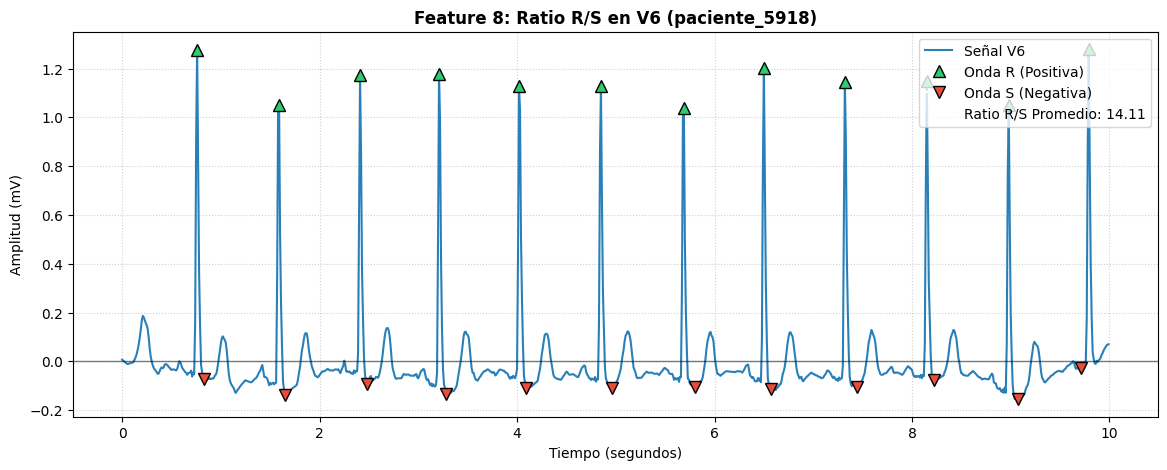

El Ratio R/S promedio en V6 para este paciente es: 14.11


In [24]:
# =============================================================================
# 3. PRUEBA GRÁFICA DE LA OCTAVA FEATURE (Paciente 5918)
# =============================================================================
print("Visualizando Feature 8 para el paciente_5918...")
ratio_v6_prueba = calcular_ratio_rs_v6(dataset_proyecto, 'paciente_5918', plot=True)
print(f"El Ratio R/S promedio en V6 para este paciente es: {ratio_v6_prueba:.2f}")

In [25]:
def calcular_r_amp_lead_I(diccionario_dataset, clave_paciente, ventana_izq_ms=80, ventana_der_ms=120, plot=False):
    """
    Mide la amplitud (altura) de la onda R en la derivación I.
    Toma el valor máximo positivo dentro del complejo QRS.
    Las ondas R muy altas y anchas en Lead I son un marcador fuerte de LBBB.
    """
    senal = diccionario_dataset[clave_paciente]['senal_I_limpia']
    fs = diccionario_dataset[clave_paciente]['fs_lr']
    picos_r = diccionario_dataset[clave_paciente]['indices_ondas_r']
    
    if picos_r is None or len(picos_r) == 0:
        return 0.0
        
    muestras_izq = int((ventana_izq_ms / 1000) * fs)
    muestras_der = int((ventana_der_ms / 1000) * fs)
    
    amplitudes_r = []
    
    if plot:
        tiempo = np.arange(len(senal)) / fs
        plt.figure(figsize=(14, 5))
        plt.plot(tiempo, senal, color='#8e44ad', lw=1.5, label='Señal Lead I')
        plt.title(f'Feature 9: Amplitud de Onda R en Lead I ({clave_paciente})', fontsize=12, fontweight='bold')
        plt.xlabel('Tiempo (segundos)')
        plt.ylabel('Amplitud (mV)')
        plt.axhline(0, color='black', lw=1, alpha=0.5)
        
    for r_idx in picos_r:
        inicio = max(0, r_idx - muestras_izq)
        fin = min(len(senal), r_idx + muestras_der)
        segmento = senal[inicio:fin]
        
        # Buscar el valor máximo en el segmento
        max_val = np.max(segmento)
        
        # Si el máximo es mayor a cero, esa es nuestra onda R. Si no, es 0.
        amp_r = max_val if max_val > 0 else 0.0
        amplitudes_r.append(amp_r)
        
        if plot and amp_r > 0:
            idx_max = inicio + np.argmax(segmento)
            # Marcar el pico de la onda R
            plt.plot(tiempo[idx_max], max_val, "^", color='#f1c40f', markersize=8, markeredgecolor='k')
            # Dibujar línea vertical mostrando la amplitud
            plt.vlines(x=tiempo[idx_max], ymin=0, ymax=max_val, color='#f39c12', linestyle='--', lw=2)
                
    # Promedio de amplitud
    amp_r_media = np.mean(amplitudes_r) if len(amplitudes_r) > 0 else 0.0
    
    # Guardar en el diccionario
    diccionario_dataset[clave_paciente]['descriptores']['r_amp_lead_I'] = amp_r_media
    
    if plot:
        leyenda_elementos = [
            plt.Line2D([0], [0], color='#8e44ad', lw=1.5, label='Señal Lead I'),
            plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='#f1c40f', markeredgecolor='k', markersize=8, label='Pico Onda R'),
            plt.Line2D([0], [0], color='#f39c12', linestyle='--', lw=2, label='Amplitud medida'),
            Patch(facecolor='none', edgecolor='none', label=f'Amplitud Promedio: {amp_r_media:.3f} mV')
        ]
        plt.legend(handles=leyenda_elementos, loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()
        
    return amp_r_media

Visualizando Feature 9 para el paciente_5918...


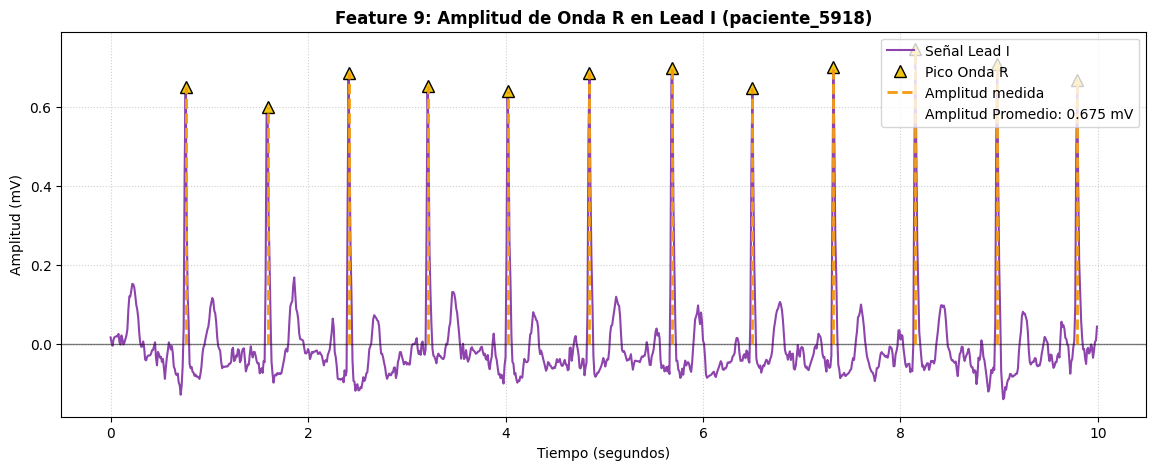

La amplitud promedio de la onda R en Lead I es: 0.675 mV


In [26]:
# =============================================================================
# 3. PRUEBA GRÁFICA DE LA NOVENA FEATURE (Paciente 5918)
# =============================================================================
print("Visualizando Feature 9 para el paciente_5918...")
amp_r_prueba = calcular_r_amp_lead_I(dataset_proyecto, 'paciente_5918', plot=True)
print(f"La amplitud promedio de la onda R en Lead I es: {amp_r_prueba:.3f} mV")

In [27]:
# =============================================================================
# 2. PROCESAMIENTO MASIVO: DETECCIÓN + FEATURES 1 A 9
# =============================================================================
print("Iniciando procesamiento masivo...")

pacientes_sin_latidos = []

for clave_paciente in dataset_proyecto:
    try:
        picos = detectar_latidos_v1(dataset_proyecto, clave_paciente, plot=False)
        
        if len(picos) > 0:
            calcular_area_qrs_v1(dataset_proyecto, clave_paciente, plot=False)
            calcular_ancho_qrs_lead_I(dataset_proyecto, clave_paciente, plot=False)
            calcular_polaridad_net_v1(dataset_proyecto, clave_paciente, plot=False)
            calcular_n_picos_pos_v1(dataset_proyecto, clave_paciente, plot=False)
            calcular_sep_r_rprime_v1(dataset_proyecto, clave_paciente, plot=False)
            calcular_ratio_rs_v1(dataset_proyecto, clave_paciente, plot=False)
            calcular_s_wave_depth_v6(dataset_proyecto, clave_paciente, plot=False)
            calcular_ratio_rs_v6(dataset_proyecto, clave_paciente, plot=False)
            calcular_r_amp_lead_I(dataset_proyecto, clave_paciente, plot=False) # NUEVA
        else:
            pacientes_sin_latidos.append(clave_paciente)
            dataset_proyecto[clave_paciente]['descriptores']['area_qrs_v1'] = 0.0
            dataset_proyecto[clave_paciente]['descriptores']['ancho_qrs_lead_I'] = 0.0
            dataset_proyecto[clave_paciente]['descriptores']['polaridad_net_v1'] = 0.0
            dataset_proyecto[clave_paciente]['descriptores']['n_picos_pos_v1'] = 0.0
            dataset_proyecto[clave_paciente]['descriptores']['sep_r_rprime_v1'] = 0.0
            dataset_proyecto[clave_paciente]['descriptores']['ratio_rs_v1'] = 0.0
            dataset_proyecto[clave_paciente]['descriptores']['s_wave_depth_v6'] = 0.0
            dataset_proyecto[clave_paciente]['descriptores']['ratio_rs_v6'] = 0.0
            dataset_proyecto[clave_paciente]['descriptores']['r_amp_lead_I'] = 0.0 # NUEVA
            
    except Exception as e:
        print(f"Error procesando {clave_paciente}: {e}")

print("✓ ¡Extracción de las Features 1 a 9 completada en todo el dataset!")

Iniciando procesamiento masivo...
✓ ¡Extracción de las Features 1 a 9 completada en todo el dataset!


In [28]:

# =============================================================================
# PASO 1: EXTRACCIÓN ASEGURADA (Sobreescribe todo con las 9 features)
# =============================================================================
print("1. Calculando features para todos los pacientes...")
pacientes_sin_latidos = []

for clave_paciente in dataset_proyecto:
    try:
        picos = detectar_latidos_v1(dataset_proyecto, clave_paciente, plot=False)
        if len(picos) > 0:
            calcular_area_qrs_v1(dataset_proyecto, clave_paciente, plot=False)
            calcular_ancho_qrs_lead_I(dataset_proyecto, clave_paciente, plot=False)
            calcular_polaridad_net_v1(dataset_proyecto, clave_paciente, plot=False)
            calcular_n_picos_pos_v1(dataset_proyecto, clave_paciente, plot=False)
            calcular_sep_r_rprime_v1(dataset_proyecto, clave_paciente, plot=False)
            calcular_ratio_rs_v1(dataset_proyecto, clave_paciente, plot=False)
            calcular_s_wave_depth_v6(dataset_proyecto, clave_paciente, plot=False)
            calcular_ratio_rs_v6(dataset_proyecto, clave_paciente, plot=False)
            calcular_r_amp_lead_I(dataset_proyecto, clave_paciente, plot=False)
        else:
            pacientes_sin_latidos.append(clave_paciente)
            for f in ['area_qrs_v1', 'ancho_qrs_lead_I', 'polaridad_net_v1', 
                      'n_picos_pos_v1', 'sep_r_rprime_v1', 'ratio_rs_v1', 
                      's_wave_depth_v6', 'ratio_rs_v6', 'r_amp_lead_I']:
                dataset_proyecto[clave_paciente]['descriptores'][f] = 0.0
    except Exception:
        pass

# =============================================================================
# PASO 2: CONSTRUCCIÓN DEL DATAFRAME
# =============================================================================
print("2. Construyendo la matriz de datos (DataFrame)...")
datos_clasificacion = []
for clave, datos in dataset_proyecto.items():
    if clave not in pacientes_sin_latidos:
        fila = datos['descriptores'].copy()
        fila['paciente'] = clave
        fila['clase_real'] = datos['clase_clinica']
        datos_clasificacion.append(fila)

df = pd.DataFrame(datos_clasificacion)

# =============================================================================
# PASO 3: IMPRESIÓN DE LA TABLA (EDA)
# =============================================================================
print("3. Generando tabla de estadísticos...\n")
features_a_analizar = ['ancho_qrs_lead_I', 'polaridad_net_v1', 'n_picos_pos_v1', 
                       'ratio_rs_v1', 's_wave_depth_v6', 'r_amp_lead_I',
                       'area_qrs_v1', 'ratio_rs_v6']
orden_clases = ['NORM', 'IRBBB', 'CRBBB', 'ILBBB', 'CLBBB']

for feature in features_a_analizar:
    print(f"➤ FEATURE: {feature.upper()}")
    resumen = df.groupby('clase_real')[feature].agg(
        Media='mean', Mediana='median', Min='min',
        Q1=lambda x: x.quantile(0.25), Q3=lambda x: x.quantile(0.75), Max='max'
    ).round(4).reindex(orden_clases)
    print(resumen.to_string())
    print("-" * 60)

1. Calculando features para todos los pacientes...
2. Construyendo la matriz de datos (DataFrame)...
3. Generando tabla de estadísticos...

➤ FEATURE: ANCHO_QRS_LEAD_I
             Media  Mediana     Min      Q1      Q3     Max
clase_real                                                 
NORM        0.1319   0.1310  0.0415  0.0961  0.1665  0.2321
IRBBB       0.1486   0.1511  0.0292  0.1144  0.1830  0.2400
CRBBB       0.1942   0.2040  0.0958  0.1707  0.2215  0.2400
ILBBB       0.1779   0.1827  0.0777  0.1629  0.1950  0.2394
CLBBB       0.1987   0.1979  0.1291  0.1837  0.2137  0.2331
------------------------------------------------------------
➤ FEATURE: POLARIDAD_NET_V1
             Media  Mediana     Min      Q1      Q3     Max
clase_real                                                 
NORM       -0.0153  -0.0144 -0.0359 -0.0212 -0.0087  0.0009
IRBBB      -0.0037  -0.0033 -0.0469 -0.0108  0.0021  0.0459
CRBBB      -0.0134  -0.0265 -0.0779 -0.0336  0.0160  0.0526
ILBBB      -0.0528  -0.

REPORTE DE CLASIFICACIÓN FINAL — Sistema Experto Heurístico v6
              precision    recall  f1-score   support

       CLBBB       0.86      0.87      0.87       100
       CRBBB       0.64      0.55      0.59        98
       ILBBB       0.50      0.27      0.35        45
       IRBBB       0.57      0.79      0.66        95
        NORM       0.66      0.65      0.65        99

    accuracy                           0.67       437
   macro avg       0.65      0.62      0.62       437
weighted avg       0.67      0.67      0.66       437



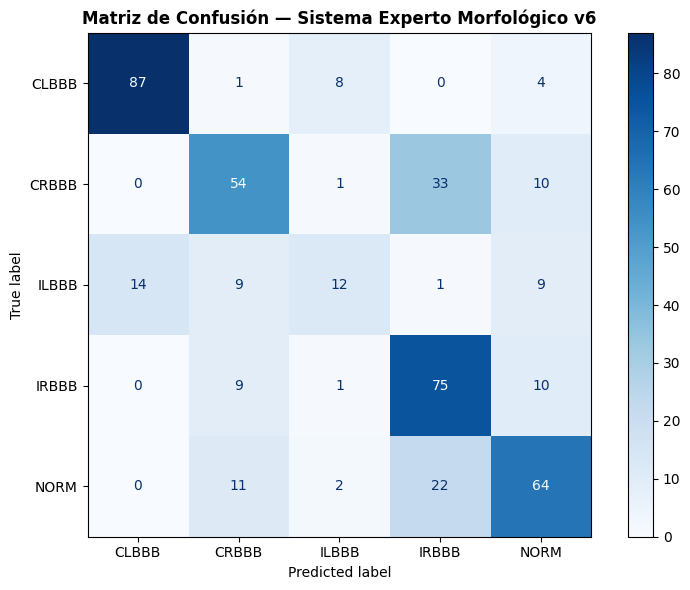

In [29]:

# =============================================================================
# CLASIFICADOR FINAL: SISTEMA EXPERTO CLÍNICO (VERSIÓN V6)
# =============================================================================

def clasificador_reglas_v6(row):
    """
    Clasificador determinista basado en reglas morfológicas y criterios
    electrofisiológicos de los cuartiles del dataset (PTB-XL).
    """
    area     = row['area_qrs_v1']         # Energía total en V1
    ancho    = row['ancho_qrs_lead_I']    # Duración en Lead I
    polar    = row['polaridad_net_v1']    # Balance neto en V1
    picos    = row['n_picos_pos_v1']      # Cantidad de picos positivos en V1
    r_amp_I  = row['r_amp_lead_I']        # Amplitud de R en Lead I
    ratio_v1 = row['ratio_rs_v1']         # Cociente R/S en V1
    ratio_v6 = row['ratio_rs_v6']         # Cociente R/S en V6

    # ------------------------------------------------------------------ #
    # 1. CLBBB (Bloqueo Completo Izquierdo)                              #
    # ------------------------------------------------------------------ #
    if area >= 0.092 and polar < -0.045:
        return 'CLBBB'
        
    if area >= 0.078 and polar < -0.065 and ancho > 0.160:
        return 'CLBBB'

    # ------------------------------------------------------------------ #
    # 2. ILBBB (Bloqueo Incompleto Izquierdo)                            #
    # ------------------------------------------------------------------ #
    if area >= 0.042 and polar < -0.032 and r_amp_I > 0.45:
        return 'ILBBB'

    # ------------------------------------------------------------------ #
    # 3. IRBBB (Bloqueo Incompleto Derecho - Patrón rSR')               #
    # ------------------------------------------------------------------ #
    if picos >= 1.68 and polar > -0.025:
        return 'IRBBB'
        
    if ratio_v1 > 0.35 and ancho > 0.120 and polar > -0.012 and r_amp_I > 0.45:
        return 'IRBBB'

    # ------------------------------------------------------------------ #
    # 4. CRBBB (Bloqueo Completo Derecho - OBJETIVO PRINCIPAL)           #
    # ------------------------------------------------------------------ #
    # Criterio de Ratio V6 (Ausencia de S) validando que no sea izquierdo
    if ratio_v6 > 500.0 and ancho > 0.145 and polar > -0.040 and area < 0.065:
        return 'CRBBB'
        
    # Criterio clásico: QRS muy ancho + R baja en Lead I (S profunda terminal)
    if ancho >= 0.165 and r_amp_I < 0.45 and polar > -0.045:
        return 'CRBBB'
        
    # Criterio de Ratio V1 dominante
    if ratio_v1 > 1.2 and ancho > 0.135 and polar > -0.035:
        return 'CRBBB'

    # ------------------------------------------------------------------ #
    # 5. NORM (Por defecto - Registro Sano)                             #
    # ------------------------------------------------------------------ #
    return 'NORM'


# =============================================================================
# EVALUACIÓN DE MÉTRICAS Y GENERACIÓN DE MATRIZ DE CONFUSIÓN
# =============================================================================

# Aplicamos las reglas al DataFrame de trabajo
df['pred_reglas_v6'] = df.apply(clasificador_reglas_v6, axis=1)

y_true = df['clase_real']
y_pred = df['pred_reglas_v6']

# Orden alfabético estricto para la consistencia de Scikit-Learn
clases_alfabetico = ['CLBBB', 'CRBBB', 'ILBBB', 'IRBBB', 'NORM']

print("=" * 60)
print("REPORTE DE CLASIFICACIÓN FINAL — Sistema Experto Heurístico v6")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=clases_alfabetico, zero_division=0))

# --- Construcción del Gráfico de la Matriz ---
fig, ax = plt.subplots(figsize=(8, 6))

# CRUCIAL: Desactiva las líneas de fondo de Jupyter que cortan los bloques azules
ax.grid(False) 

cm = confusion_matrix(y_true, y_pred, labels=clases_alfabetico)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases_alfabetico)
disp.plot(ax=ax, colorbar=True, cmap='Blues')

ax.set_title('Matriz de Confusión — Sistema Experto Morfológico v6', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()